In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings('ignore')

## Review purchase data

In [39]:
df = pd.read_csv("/kaggle/input/face-clean-ecomer/data_reviews_purchase.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
display(df.head())

,user_id,product_id,rating,product_name_x,cmt_date,shop_id,variation_x,product_quality,processed_comment
0,0,0,4,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:28:25,0,Simple,4.0,mùi hương ko bít dành cho da tùy da công da an...
1,1,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-03 12:18:12,0,Simple,5.0,mùi nhẹ dành cho da mọi loại da công_dụng rửa ...
2,2,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-05 04:57:08,0,Simple,5.0,công_dụng rửa mặt_hàng giao rất nhanh sản_phẩm...
3,3,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:07:48,0,Simple,5.0,lần thứ 2 mua sp simple thì ai cũng biết lành_...
4,4,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-31 06:21:50,0,Simple,5.0,mua lần hai rồi dùng rất thích mọi người nên m...


In [3]:
print("Togn so luong danh gia:", df.shape[0])
print("Tong so san pham", df["product_id"].unique().shape[0])
print("Tong so nguoi dung:", df["user_id"].unique().shape[0])

Togn so luong danh gia: 369099
Tong so san pham 2231
Tong so nguoi dung: 304708


In [4]:
print(df.columns)

Index(['user_id', 'product_id', 'rating', 'product_name_x', 'cmt_date',
       'shop_id', 'variation_x', 'product_quality', 'processed_comment'],
      dtype='object')


In [5]:
print(df.shape)
print(df.info())
display(df.describe().T)

(369099, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369099 entries, 0 to 369098
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_id            369099 non-null  int64  
 1   product_id         369099 non-null  int64  
 2   rating             369099 non-null  int64  
 3   product_name_x     369099 non-null  object 
 4   cmt_date           369099 non-null  object 
 5   shop_id            369099 non-null  int64  
 6   variation_x        369099 non-null  object 
 7   product_quality    369099 non-null  float64
 8   processed_comment  359418 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 25.3+ MB
None


,count,mean,std,min,25%,50%,75%,max
user_id,369099.0,147793.021338,87525.773005,0.0,71391.5,146230.0,222734.5,304707.0
product_id,369099.0,541.538408,528.220673,0.0,156.0,376.0,707.0,2235.0
rating,369099.0,4.922598,0.428819,1.0,5.0,5.0,5.0,5.0
shop_id,369099.0,256.031119,262.583847,0.0,46.0,180.0,365.0,1287.0
product_quality,369099.0,4.926283,0.412555,1.0,5.0,5.0,5.0,5.0


In [40]:
df["cmt_date"] = pd.to_datetime(df["cmt_date"])

In [7]:
# df when processed_comment is null
display(df[df["processed_comment"].isnull()])
print("Number of null comment:", len(df[df["processed_comment"].isnull()]))

,user_id,product_id,rating,product_name_x,cmt_date,shop_id,variation_x,product_quality,processed_comment
67,67,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-15 09:33:52,0,Simple,5.0,NaN
82,82,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-10 05:26:22,0,Simple,5.0,NaN
268,67,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-09-24 13:01:50,0,Simple,5.0,NaN
577,555,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2021-12-11 13:35:49,0,Simple,5.0,NaN
1278,1235,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-06-28 06:09:37,0,Simple,5.0,NaN
...,...,...,...,...,...,...,...,...,...
369017,304636,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2020-09-06 15:12:27,372,one_variation,5.0,NaN
369039,304657,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2021-08-21 14:09:03,372,one_variation,5.0,NaN
369051,304668,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2021-04-24 08:10:50,372,one_variation,5.0,NaN
369057,304672,2232,5,Sữa rửa mặt sủi bọt thải độc chiết xuất rau củ...,2021-06-05 10:08:51,372,one_variation,5.0,NaN


Number of null comment: 9681


In [8]:
sorted(df["product_quality"].unique())

[1.0, 2.0, 3.0, 4.0, 5.0]

In [65]:
# Number of low-rated reviews
len(df[(df["rating"] == 1) | (df["rating"] == 2) | (df["rating"] == 3)])

6786

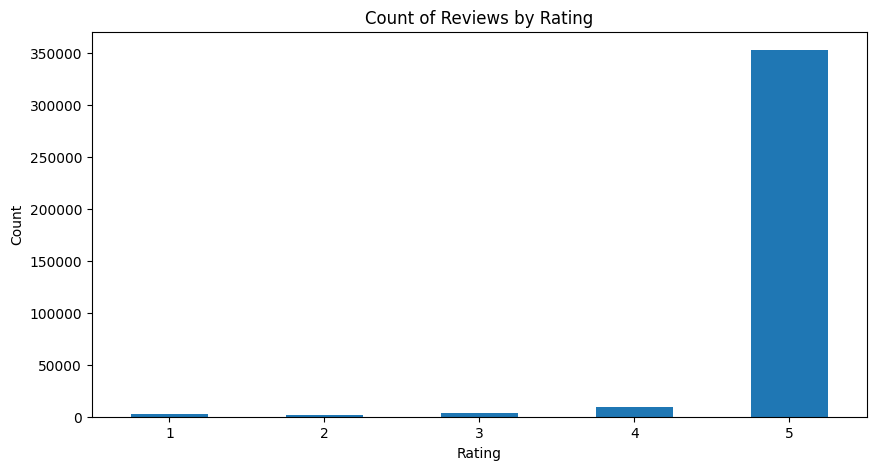

In [9]:
# plot count of reviews by rating
df["rating"].value_counts().sort_index().plot(kind="bar", figsize=(10, 5))
plt.title("Count of Reviews by Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [41]:
df_sorted = df.sort_values(by=["user_id", "cmt_date"], ascending=[True, False])
display(df_sorted.head(10))

,user_id,product_id,rating,product_name_x,cmt_date,shop_id,variation_x,product_quality,processed_comment
0,0,0,4,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:28:25,0,Simple,4.0,mùi hương ko bít dành cho da tùy da công da an...
1,1,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-03 12:18:12,0,Simple,5.0,mùi nhẹ dành cho da mọi loại da công_dụng rửa ...
2,2,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-05 04:57:08,0,Simple,5.0,công_dụng rửa mặt_hàng giao rất nhanh sản_phẩm...
3,3,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-06 12:07:48,0,Simple,5.0,lần thứ 2 mua sp simple thì ai cũng biết lành_...
793,3,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-01-18 04:51:54,0,Simple,5.0,shop đóng_gói chắc_chắn có xốp chưa sử_dụng nh...
4,4,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-31 06:21:50,0,Simple,5.0,mua lần hai rồi dùng rất thích mọi người nên m...
5,5,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-07 01:50:52,0,Simple,5.0,công_dụng rua mat mùi hương kh mui dành cho da...
6,6,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2023-01-05 03:44:20,0,Simple,5.0,ko có túi chống sốc trước có sử_dụng sp này r ...
7,7,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-27 04:36:07,0,Simple,5.0,công_dụng rửa mặt mùi dành cho da nhạy_cảm_thấ...
8,8,0,5,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,2022-12-26 17:38:04,0,Simple,5.0,tháng bảy năm 2010 del rey ký hợp_đồng thu âm ...


In [16]:
# tim chi muc cho cap user - item duoc comment gan day nhat
index = df_sorted.groupby(["user_id", "product_id"])["cmt_date"].idxmax()
# Tao DataFrame de luu tuong tac user - item gan nhat de tranh trung lap
df_no_dup = df_sorted.loc[index, ["user_id", "product_id", "rating", "cmt_date"]].sort_values(
    by=["user_id", "product_id"], ascending=False
)
df_no_dup

,user_id,product_id,rating,cmt_date
369098,304707,2235,5,2022-04-07 09:06:41
369097,304706,2235,5,2022-03-23 12:25:23
369096,304705,2235,5,2022-08-14 05:28:51
369095,304704,2235,5,2022-10-11 10:01:38
369093,304703,2235,5,2022-09-01 16:15:22
...,...,...,...,...
4,4,0,5,2022-12-31 06:21:50
3,3,0,5,2023-01-06 12:07:48
2,2,0,5,2023-01-05 04:57:08
1,1,0,5,2023-01-03 12:18:12


In [15]:
user_count = df_no_dup["user_id"].value_counts()
user_count[user_count >= 3]

176302    12
22708     12
13780     11
15488     10
101438     9
          ..
31968      3
141162     3
142235     3
38123      3
38086      3
Name: user_id, Length: 3952, dtype: int64

In [70]:
# Select 3952 user_id interacting with at least 3 products
list_user = df_no_dup["user_id"].value_counts()[:3952]
df_purchase = df_no_dup[df_no_dup["user_id"].isin(list_user.index)]
df_purchase

,user_id,product_id,cmt_date
368653,295796,2221,2022-12-21 06:46:28
358799,295796,1951,2022-09-19 07:23:34
357355,295796,1886,2022-11-18 06:39:16
353053,290595,1814,2022-11-12 12:03:30
350845,290595,1768,2022-12-13 13:23:02
...,...,...,...
159936,254,308,2023-01-05 03:30:48
257,254,0,2022-08-17 03:59:49
93092,40,159,2022-12-20 13:03:12
3688,40,1,2022-12-20 13:03:12


In [71]:
# sort by user_id and cmt_date descending
df_purchase = df_purchase.sort_values(by=["user_id", "cmt_date"], ascending=False)
df_purchase.head(20)

,user_id,product_id,cmt_date
368653,295796,2221,2022-12-21 06:46:28
357355,295796,1886,2022-11-18 06:39:16
358799,295796,1951,2022-09-19 07:23:34
350845,290595,1768,2022-12-13 13:23:02
353053,290595,1814,2022-11-12 12:03:30
350488,290595,1763,2022-05-13 09:39:35
348543,289116,1711,2021-10-01 04:15:25
352926,289116,1808,2021-09-20 04:03:43
364524,289116,2092,2020-04-07 12:20:56
367560,285040,2191,2022-03-30 12:26:07


In [72]:
# df_purchase.to_csv('../data/data_purchase.csv', index=False)

## Products Data

In [14]:
df_product = pd.read_csv("../data/data_product.csv")
display(df_product)

,avg_star,num_sold_time,price,variation,product_id,shop_id,product_name,brand,storage,origin,type,skin_kind,is_5_star,is_4_star,is_3_star,is_2_star,is_1_star,is_commented,is_image,num_rating,processed_description,expiry,send_from,image_path
0,4.8,185700,99000.0,one_variation,0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,18081.0,no_origin,no_type,no_skin,60700,2700,1200,640,1600,42200,37900,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,no_expiry,tp. hồ chí minh,111138057_8587034871.jpg
1,4.8,102600,99000.0,one_variation,1,0,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,9857.0,no_origin,no_type,no_skin,33200,1600,709,320,723,22700,20400,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,no_expiry,tp. hồ chí minh,111138057_8287055694.jpg
2,4.9,8100,244000.0,"['Phiên bản 2022 (80g)', 'Phiên bản 2023(100g)']",2,1,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,95.0,Việt Nam,dạng kem,no_skin,2500,97,25,8,14,886,618,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,24,hà nội,21080428_9335942418.mp4
3,4.9,3600,119000.0,one_variation,3,2,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,264.0,Việt Nam,dạng sánh,Da hỗn hợp,168,8,3,0,1,92,63,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,24,hà nội,758111427_19601743242.mp4
4,4.8,26300,9900.0,one_variation,4,3,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,987914.0,no_origin,no_type,no_skin,5700,349,150,52,61,3200,2300,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,no_expiry,hà nội,107632788_3330988133.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,5.0,872,82000.0,"['Trắng ( Trắng da ).', 'Xanh ( collagen ) .',...",2239,1288,Sữa rửa mặt Kose Softymo Nhật Bản 220g,KOSÉ,1406.0,no_origin,no_type,no_skin,264,5,1,0,0,126,121,270,sữa rửa mặt kose nhật bản best của best luôn a...,no_expiry,hà nội,294293046_5445658669.jpg
2240,5.0,43,205000.0,"['Tuýp 50ml', '200ml', '300ml', '400ml']",2240,1289,Sữa rửa mặt La Roche-Posay Effaclar chuyên dàn...,La Roche-Posay,274.0,Pháp,dạng gel,"Da mụn trứng cá, Da hỗn hợp, Dầu, Nhạy cảm",12,0,0,0,0,3,3,12,sữa rửa mặt la efaclar foaming gel sẽ giúp ngă...,24,tp. hồ chí minh,97333460_10761076591.jpg
2241,4.9,823,75000.0,"['Hồng', 'Collagen', 'White']",2241,1290,Sữa rửa mặt Kose Softymo Nhật Bản 220g,no_brand,172.0,no_origin,no_type,no_skin,210,4,2,0,2,124,106,218,sữa rửa mặt kose softymo là sản_phẩm sữa rửa m...,no_expiry,hà nội,315629668_3455178555.jpg
2242,5.0,1000,79000.0,one_variation,2242,407,Sữa Rửa Mặt Làm Sáng Da Reihaku Hatomugi Facia...,HATOMUGI,87.0,Nhật Bản,no_type,no_skin,428,7,4,0,0,192,181,439,thương_hiệu reihaku hatomugi xuất_xứ nhật bản ...,no_expiry,tp. hồ chí minh,258099521_6677227750.jpg


In [15]:
df_product.columns

Index(['avg_star', 'num_sold_time', 'price', 'variation', 'product_id',
       'shop_id', 'product_name', 'brand', 'storage', 'origin', 'type',
       'skin_kind', 'is_5_star', 'is_4_star', 'is_3_star', 'is_2_star',
       'is_1_star', 'is_commented', 'is_image', 'num_rating',
       'processed_description', 'expiry', 'send_from', 'image_path'],
      dtype='object')

In [16]:
df_product.drop(
    columns=[
        "variation",
        "shop_id",
        "storage",
        "is_5_star",
        "is_4_star",
        "is_3_star",
        "is_2_star",
        "is_1_star",
        "is_commented",
        "is_image",
        "expiry",
        "send_from",
    ],
    inplace=True,
)
df_product.head()

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg
2,4.9,8100,244000.0,2,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,Việt Nam,dạng kem,no_skin,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,21080428_9335942418.mp4
3,4.9,3600,119000.0,3,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,Việt Nam,dạng sánh,Da hỗn hợp,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,758111427_19601743242.mp4
4,4.8,26300,9900.0,4,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg


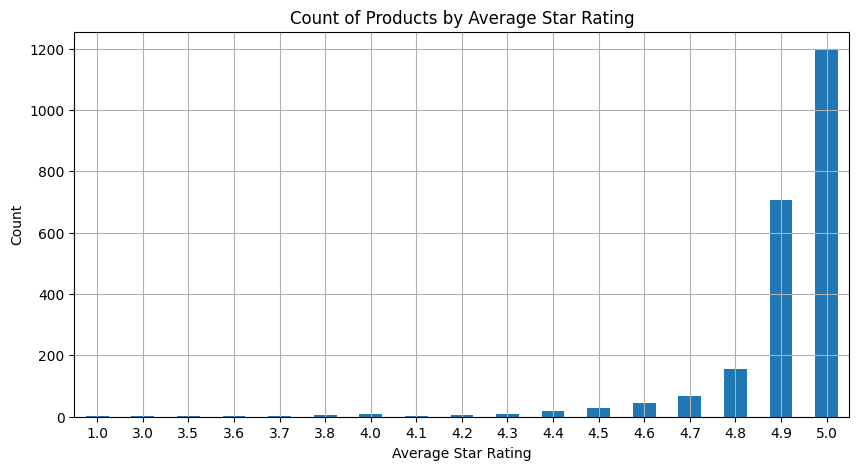

In [17]:
df_product["avg_star"].value_counts().sort_index().plot(kind="bar", figsize=(10, 5))
plt.title("Count of Products by Average Star Rating")
plt.xlabel("Average Star Rating")
plt.ylabel("Count")
plt.grid()
plt.xticks(rotation=0)
plt.show()

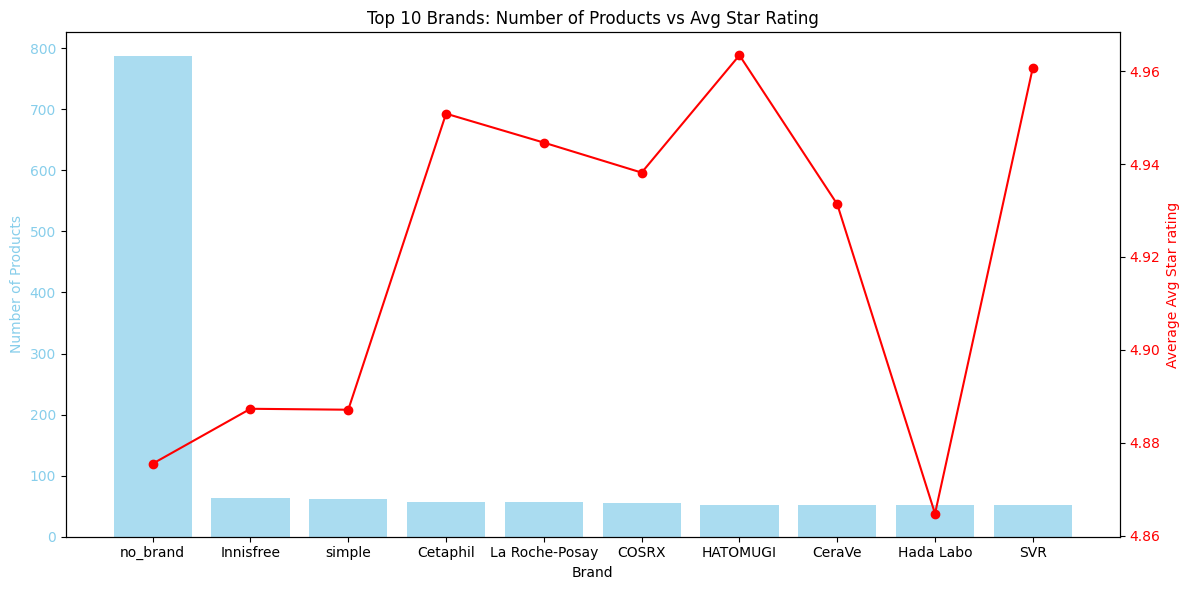

In [18]:
# Group by brand and calculate metrics
brand_metrics = (
    df_product.groupby("brand")
    .agg({"product_id": "count", "avg_star": "mean"})
    .reset_index()
)

# Sort by number of products and get top 10
top_10_brands = brand_metrics.nlargest(10, "product_id")

# Create a figure with dual axis
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Plot bars for number of products
bars = ax1.bar(
    top_10_brands["brand"], top_10_brands["product_id"], color="skyblue", alpha=0.7
)
ax1.set_xlabel("Brand")
ax1.set_ylabel("Number of Products", color="skyblue")
ax1.tick_params(axis="y", labelcolor="skyblue")

# Plot line for average popularity score
line = ax2.plot(
    top_10_brands["brand"], top_10_brands["avg_star"], color="red", marker="o"
)
ax2.set_ylabel("Average Avg Star rating", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Brands: Number of Products vs Avg Star Rating")
plt.tight_layout()
plt.show()

In [12]:
top_10_brands

,brand,product_id,avg_star
270,no_brand,787,4.875476
129,Innisfree,63,4.887302
273,simple,62,4.887097
50,Cetaphil,57,4.950877
151,La Roche-Posay,56,4.944643
47,COSRX,55,4.938182
110,HATOMUGI,52,4.963462
49,CeraVe,51,4.931373
116,Hada Labo,51,4.864706
217,SVR,51,4.960784


In [20]:
# Calculate popularity score for each product based on number of sold, number of ratings, and average star rating
df_product["normalized_sold"] = (
    df_product["num_sold_time"] / df_product["num_sold_time"].max()
)
df_product["normalized_avg_star"] = (
    df_product["avg_star"] / df_product["avg_star"].max()
)
df_product["normalized_rating"] = (
    df_product["num_rating"] / df_product["num_rating"].max()
)

sold_weight = 0.5
avg_star_weight = 0.3
rating_weight = 0.2

df_product["popularity_score"] = (
    sold_weight * df_product["normalized_sold"]
    + rating_weight * df_product["normalized_rating"]
    + avg_star_weight * df_product["normalized_avg_star"]
)

df_product.drop(
    columns=["normalized_sold", "normalized_rating", "normalized_avg_star"],
    inplace=True,
)
df_product

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path,popularity_score
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg,0.988000
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg,0.673624
2,4.9,8100,244000.0,2,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,Việt Nam,dạng kem,no_skin,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,21080428_9335942418.mp4,0.323721
3,4.9,3600,119000.0,3,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,Việt Nam,dạng sánh,Da hỗn hợp,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,758111427_19601743242.mp4,0.304232
4,4.8,26300,9900.0,4,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg,0.377700
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,5.0,872,82000.0,2239,Sữa rửa mặt Kose Softymo Nhật Bản 220g,KOSÉ,no_origin,no_type,no_skin,270,sữa rửa mặt kose nhật bản best của best luôn a...,294293046_5445658669.jpg,0.303156
2240,5.0,43,205000.0,2240,Sữa rửa mặt La Roche-Posay Effaclar chuyên dàn...,La Roche-Posay,Pháp,dạng gel,"Da mụn trứng cá, Da hỗn hợp, Dầu, Nhạy cảm",12,sữa rửa mặt la efaclar foaming gel sẽ giúp ngă...,97333460_10761076591.jpg,0.300152
2241,4.9,823,75000.0,2241,Sữa rửa mặt Kose Softymo Nhật Bản 220g,no_brand,no_origin,no_type,no_skin,218,sữa rửa mặt kose softymo là sản_phẩm sữa rửa m...,315629668_3455178555.jpg,0.296868
2242,5.0,1000,79000.0,2242,Sữa Rửa Mặt Làm Sáng Da Reihaku Hatomugi Facia...,HATOMUGI,Nhật Bản,no_type,no_skin,439,thương_hiệu reihaku hatomugi xuất_xứ nhật bản ...,258099521_6677227750.jpg,0.304006


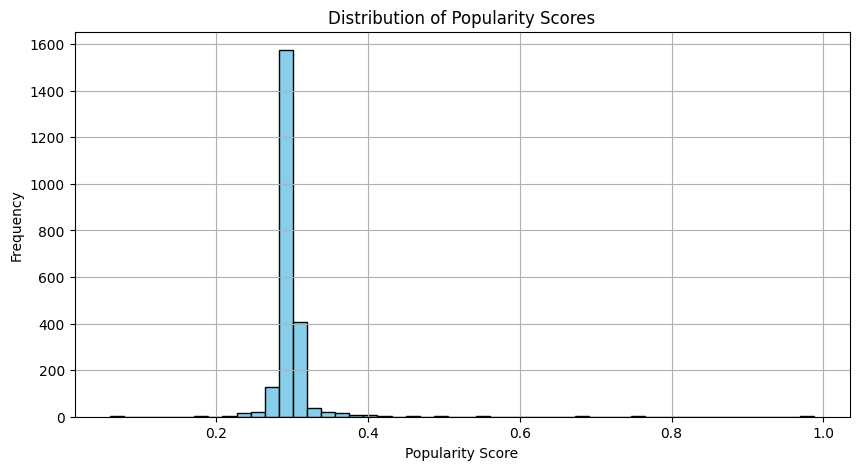

In [25]:
# Plot distribution of popularity scores
plt.figure(figsize=(10, 5))
df_product["popularity_score"].plot(
    kind="hist", bins=50, color="skyblue", edgecolor="black"
)
plt.title("Distribution of Popularity Scores")
plt.xlabel("Popularity Score")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [29]:
# Filter products from top 10 brands with avg_star >= 4
top_brand_products = df_product[
    (df_product["brand"].isin(top_10_brands["brand"]))
    & (df_product["popularity_score"] >= 0.3)
]
display(top_brand_products)

# Save the filtered products to a new CSV file
top_brand_products.to_csv("../data/top_brand_products.csv", index=False)

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path,popularity_score
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg,0.988000
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg,0.673624
4,4.8,26300,9900.0,4,🌈🍒🍭 Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp D...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg,0.377700
8,5.0,8,19900.0,8,Sữa rửa mặt giảm nám và chống tàn nhang Đông Y...,no_brand,no_origin,no_type,no_skin,2,check_mark công_dụng giúp làm mờ các mảng nám ...,102812033_21347751073.jpg,0.300028
9,5.0,2100,329000.0,9,Sữa Rửa Mặt SVR Sebiaclear Gel Moussant 400ml ...,SVR,Pháp,no_type,"Da mụn trứng cá, Mọi loại da, Da hỗn hợp",684,sữa rửa mặt svr gel mousant 40 ml gel rửa mặt ...,425554589_19931947987.jpg,0.307701
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2234,5.0,170,56000.0,2234,3 chai sữa rửa mặt con Bò Làm Trắng Da,no_brand,Trung Quốc,dạng lỏng,Mọi loại da,44,điểm nổi_bật sữa rửa mặt lyolan tẩy tế_bào chế...,27729807_515650941.jpg,0.300589
2236,5.0,136,732500.0,2236,Sữa rửa mặt Tẩy da chết Civasan Enzyme Noraxis...,no_brand,no_origin,no_type,no_skin,33,sản_phẩm an_toàn cho cả da hoàn_toàn không gây...,44469878_20733411206.jpg,0.300465
2237,5.0,733,294000.0,2237,Sữa rửa mặt Aderma,no_brand,no_origin,no_type,no_skin,299,sữa rửa mặt aderma với thành_phần lành_tính từ...,6915796_7266518732.jpg,0.302868
2240,5.0,43,205000.0,2240,Sữa rửa mặt La Roche-Posay Effaclar chuyên dàn...,La Roche-Posay,Pháp,dạng gel,"Da mụn trứng cá, Da hỗn hợp, Dầu, Nhạy cảm",12,sữa rửa mặt la efaclar foaming gel sẽ giúp ngă...,97333460_10761076591.jpg,0.300152


In [9]:
# import re

# def remove_emoji(text):
#     emoji_pattern = re.compile(
#         "["
#         "\U0001F600-\U0001F64F"  # emoticons
#         "\U0001F300-\U0001F5FF"  # symbols & pictographs
#         "\U0001F680-\U0001F6FF"  # transport & map symbols
#         "\U0001F1E0-\U0001F1FF"  # flags (iOS)
#         "\U00002700-\U000027BF"  # Dingbats
#         "\U000024C2-\U0001F251"
#         "]+", flags=re.UNICODE
#     )
#     return emoji_pattern.sub(r'', text)

# df_product['product_name'] = df_product['product_name'].apply(remove_emoji)
# df_product['brand'] = df_product['brand'].apply(remove_emoji)
# df_product.head()

In [90]:
df_product["combined_text"] = (
    df_product["product_name"]
    + " [BRAND] "
    + df_product["brand"]
    + " [ORIGIN] "
    + df_product["origin"]
    + " [TYPE] "
    + df_product["type"]
    + " [SKIN KIND] "
    + df_product["skin_kind"]
    + " [DESC] "
    + df_product["processed_description"]
)
df_product.head()

,avg_star,num_sold_time,price,product_id,product_name,brand,origin,type,skin_kind,num_rating,processed_description,image_path,popularity_score,combined_text
0,4.8,185700,99000.0,0,Sữa rửa mặt Simple lành tính sạch thoáng - cho...,simple,no_origin,no_type,no_skin,66840,ưu_điểm nổi_trội sữa rửa mặt simple lành_tính ...,111138057_8587034871.jpg,0.988000,Sữa rửa mặt Simple lành tính sạch thoáng - cho...
1,4.8,102600,99000.0,1,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...,simple,no_origin,no_type,no_skin,36552,ưu_điểm nổi_trội sữa rửa mặt simple giúp kiềm ...,111138057_8287055694.jpg,0.673624,Sữa rửa mặt Simple giúp kiềm dầu và ngừa mụn h...
2,4.9,8100,244000.0,2,Sữa rửa mặt nam 30Shine phân phối chính hãng S...,Skin&Dr\t,Việt Nam,dạng kem,no_skin,2644,sữa rửa mặt nam skin dr tràm trà 80 g cho da m...,21080428_9335942418.mp4,0.323721,Sữa rửa mặt nam 30Shine phân phối chính hãng S...
3,4.9,3600,119000.0,3,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...,RHYS MAN,Việt Nam,dạng sánh,Da hỗn hợp,180,chính hãng sữa rửa mặt nam rhys man rhys cocon...,758111427_19601743242.mp4,0.304232,Sữa rửa mặt nam RHYS MAN Rhys Coconut Fresh hư...
4,4.8,26300,9900.0,4,Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp Da T...,no_brand,no_origin,no_type,no_skin,6312,sỉ tốt 13 k c bao giá sl toàn_quốc ngại j khôn...,107632788_3330988133.jpg,0.377700,Sữa Rửa Mặt Senana Lấy Sạch Bụi Bẩn Giúp Da T...


In [6]:
df_product.columns

Index(['avg_star', 'num_sold_time', 'price', 'product_id', 'product_name',
       'brand', 'origin', 'type', 'skin_kind', 'num_rating',
       'processed_description', 'image_path', 'popularity_score',
       'combined_text'],
      dtype='object')

In [ ]:
# df_product.to_csv('../data/data_product_combine.csv', index=False)

### 3. Prepare data for Collaborative Filtering


In [42]:
# tim chi muc cho cap user - item duoc comment gan day nhat
index = df_sorted.groupby(["user_id", "product_id"])["cmt_date"].idxmax()
# Tao DataFrame de luu tuong tac user - item gan nhat de tranh trung lap
df_no_dup = df_sorted.loc[index, ["user_id", "product_id", "rating", "cmt_date"]].sort_values(
    by=["user_id", "product_id"], ascending=False
)
df_no_dup

,user_id,product_id,rating,cmt_date
369098,304707,2235,5,2022-04-07 09:06:41
369097,304706,2235,5,2022-03-23 12:25:23
369096,304705,2235,5,2022-08-14 05:28:51
369095,304704,2235,5,2022-10-11 10:01:38
369093,304703,2235,5,2022-09-01 16:15:22
...,...,...,...,...
4,4,0,5,2022-12-31 06:21:50
3,3,0,5,2023-01-06 12:07:48
2,2,0,5,2023-01-05 04:57:08
1,1,0,5,2023-01-03 12:18:12


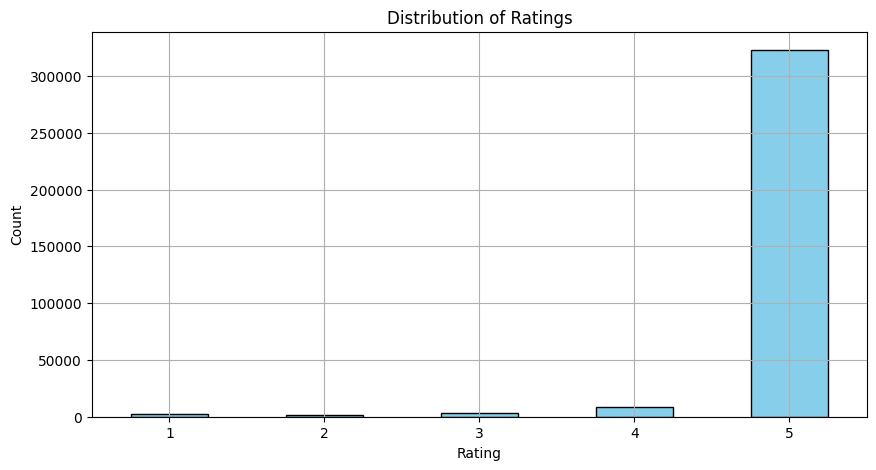

In [6]:
# plot distribution of ratings
plt.figure(figsize=(10, 5))
df_no_dup["rating"].value_counts().sort_index().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid()
plt.show()


In [43]:
user_count = df_no_dup["user_id"].value_counts()
user_count[user_count >= 2]

user_id
22708     12
176302    12
13780     11
15488     10
133622     9
          ..
18294      2
6870       2
279694     2
17995      2
6432       2
Name: count, Length: 28477, dtype: int64

In [44]:
list_user = df_no_dup["user_id"].value_counts()[:28477]
df_cleaned = df_no_dup[df_no_dup["user_id"].isin(list_user.index)]
df_cleaned

,user_id,product_id,rating,cmt_date
367712,303176,2196,5,2019-12-13 08:29:58
367100,303176,2185,5,2021-06-17 21:12:47
367670,303166,2196,5,2022-05-13 20:30:30
367083,303166,2185,5,2021-09-13 06:57:28
367841,303120,2197,5,2021-03-29 13:50:03
...,...,...,...,...
40,40,0,3,2022-12-20 13:03:12
33534,29,39,5,2022-03-13 08:00:29
29,29,0,4,2022-12-27 07:59:50
116484,14,204,5,2022-08-14 08:26:09


In [52]:
print(len(df_cleaned.user_id.unique()))
print(len(df_cleaned.product_id.unique()))

28477
1884


In [59]:
# Bước 1: Tạo DataFrame mới để không ảnh hưởng đến dữ liệu gốc
df_time_split = df_cleaned.copy()

# Bước 2: Với mỗi người dùng, lấy ra đánh giá gần đây nhất cho tập test

# Tạo một cột mới để đánh dấu đánh giá gần đây nhất của mỗi người dùng
df_time_split['is_most_recent'] = ~df_time_split.duplicated('user_id')

# Tạo tập test (chỉ chứa đánh giá gần đây nhất của mỗi người dùng)
test_set = df_time_split[df_time_split['is_most_recent']]
test_set = test_set.drop(columns=['is_most_recent'])  # Loại bỏ cột đánh dấu

# Tạo tập train (chứa tất cả đánh giá còn lại)
train_set = df_time_split[~df_time_split['is_most_recent']]
train_set = train_set.drop(columns=['is_most_recent'])  # Loại bỏ cột đánh dấu

# Kiểm tra kết quả
print(f"Số lượng đánh giá trong tập huấn luyện: {len(train_set)}")
print(f"Số lượng người dùng trong tập kiểm tra: {train_set['user_id'].nunique()}")
print(f"Số lượng sản phẩm trong tập kiểm tra: {train_set['product_id'].nunique()}")
print(f"Số lượng đánh giá trong tập kiểm tra: {len(test_set)}")
print(f"Số lượng người dùng trong tập kiểm tra: {test_set['user_id'].nunique()}")
print(f"Số lượng sản phẩm trong tập kiểm tra: {test_set['product_id'].nunique()}")

Số lượng đánh giá trong tập huấn luyện: 33336
Số lượng người dùng trong tập kiểm tra: 28477
Số lượng sản phẩm trong tập kiểm tra: 1271
Số lượng đánh giá trong tập kiểm tra: 28477
Số lượng người dùng trong tập kiểm tra: 28477
Số lượng sản phẩm trong tập kiểm tra: 1711


In [62]:
train_set.to_csv('./train.csv', index=False)
test_set.to_csv('./test.csv', index=False)

In [59]:
train_df = pd.read_csv("/kaggle/working/train.csv")
train_df = train_df.pivot_table(index='user_id', columns='product_id', values='rating')
test_df = pd.read_csv("/kaggle/working/test.csv")
test_df = test_df.pivot_table(index='user_id', columns='product_id', values='rating')

In [ ]:
user_item_matrix = df_cleaned.pivot_table(index='user_id', columns='product_id', values='rating')
user_item_matrix.head()

In [15]:
# user_item_matrix.to_csv('./user_item_matrix.csv', index=True)

In [12]:
import pandas as pd
usr_item_mx = pd.read_csv("./user_item_matrix.csv")
df = usr_item_mx.set_index("user_id")
df.head()

0    1   2   3   4   9  10  11  13  14  15  16  18  19  20  21  22  \
user_id                                                                         
14       5.0  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
29       4.0  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
40       3.0  3.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
43       5.0  NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
44       5.0  5.0 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

         23  24  25  26  27  28  29  30  31  32  34  35  36  37  38   39  40  \
user_id                                                                        
14      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN NaN   
29      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  5.0 NaN   
40      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN NaN   
43      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN NaN   
44      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN NaN   

         41  44  45  46  47  48  49  50  51  52  53  54  56  57  58  59  60  \
user_id                                                                       
14      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
29      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
40      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
43      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
44      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

         61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  \
user_id                                                                       
14      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
29      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
40      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
43      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
44      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

         78  79  81  82  83  85  86  87  88  89  90  91  93  94  96  97  98  \
user_id                                                                       
14      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
29      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
40      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
43      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   
44      NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN   

         99  100  101  102  103  105  106  107  108  110  111  112  113  114  \
user_id                                                                        
14      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
29      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
40      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
43      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
44      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

         115  117  118  120  121  122  123  124  125  126  127  128  129  130  \
user_id                                                                         
14       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
29       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
40       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
43       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
44       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

         131  132  133  134  135  137  138  139  141  142  143  144  145  146  \
user_id   

In [19]:
# Số ô có giá trị (không bị NaN)
non_null_count = df.count().sum()

# Tổng số ô trong ma trận
total_cells = df.shape[0] * df.shape[1]

# Tính mật độ
density = non_null_count / total_cells * 100

print(f"Num ratings: {non_null_count}")
print(f"Num users: {df.shape[0]}")
print(f"Num items: {df.shape[1]}")
print(f"Mật độ ma trận: {density:.2f}%")

Num ratings: 61813
Num users: 28477
Num items: 1884
Mật độ ma trận: 0.12%


In [64]:
class MatrixFactorizationPyTorch(nn.Module):
    def __init__(self, train_data, test_data, k, alpha, lam, max_iters=1000, device="cuda"):
        """
        @params
          - train_data: dataframe train với dòng~user, cột~item, value ~ rating
          - test_data: dataframe test với dòng~user, cột~item, value ~ rating
          - K: số chiều của nhân tố ẩn, cho cả U và V
          - alpha : cỡ bước (learning rate)
          - lam : tham số hiệu chỉnh (regularization parameter)
          - max_iters: số vòng lặp
          - device: thiết bị tính toán ('cuda' hoặc 'cpu')
        """
        super(MatrixFactorizationPyTorch, self).__init__()
        
        self.train_data = train_data
        self.test_data = test_data
        self.R = self.train_data.to_numpy()
        self.m, self.n = self.train_data.shape
        self.k = k
        self.max_iters = max_iters
        
        # Xác định thiết bị tính toán (GPU hoặc CPU)
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")
        
        # Khởi tạo các tham số mô hình dưới dạng PyTorch Parameters
        self.U = nn.Parameter(torch.randn(self.m, k, device=self.device))
        self.V = nn.Parameter(torch.randn(self.n, k, device=self.device))
        self.b_user = nn.Parameter(torch.zeros(self.m, device=self.device))
        self.b_item = nn.Parameter(torch.zeros(self.n, device=self.device))
        
        # Khởi tạo các siêu tham số
        self.alpha = alpha
        self.lam = lam
        
        # Tạo mask cho các phần tử không bị khuyết
        self.mask = torch.from_numpy(~np.isnan(self.R)).float().to(self.device)
        
        # Chuyển ma trận R sang tensor và xử lý giá trị NaN
        R_tensor = torch.from_numpy(np.nan_to_num(self.R, nan=0)).float().to(self.device)
        self.R_tensor = R_tensor
        
        # Chuẩn bị dữ liệu test
        self.test_R = self.test_data.to_numpy()
        self.test_mask = torch.from_numpy(~np.isnan(self.test_R)).float().to(self.device)
        self.test_R_tensor = torch.from_numpy(np.nan_to_num(self.test_R, nan=0)).float().to(self.device)

    def forward(self):
        """
        Dự đoán toàn bộ ma trận ratings
        """
        # Tính toán ma trận dự đoán đầy đủ
        predicted_R = self.b_user.unsqueeze(1) + self.b_item.unsqueeze(0) + torch.matmul(self.U, self.V.t())
        
        # Giới hạn giá trị dự đoán trong khoảng [1, 5]
        predicted_R = torch.clamp(predicted_R, 1.0, 5.0)
        
        return predicted_R
    
    def get_rating(self, i, j):
        """
        Dự đoán rating của user i đối với item j
        """
        with torch.no_grad():
            prediction = self.b_user[i] + self.b_item[j] + torch.dot(self.U[i], self.V[j])
            prediction = torch.clamp(prediction, 1.0, 5.0)
            
        return prediction.item()
    
    def rmse(self, is_test=False):
        """
        Hàm tính căn bậc hai trung bình bình phương sai số (RMSE)
        
        @params
          - is_test: nếu True thì tính RMSE trên tập test, ngược lại trên tập train
        """
        with torch.no_grad():
            # Lấy dự đoán
            predicted = self.forward()
            
            if is_test:
                # Tính RMSE trên tập test
                squared_error = self.test_mask * (self.test_R_tensor - predicted) ** 2
                mse = torch.sum(squared_error) / torch.sum(self.test_mask)
            else:
                # Tính RMSE trên tập train
                squared_error = self.mask * (self.R_tensor - predicted) ** 2
                mse = torch.sum(squared_error) / torch.sum(self.mask)
                
            rmse = torch.sqrt(mse)
            
        return rmse.item()
    
    def mae(self, is_test=False):
        """
        Hàm tính trung bình sai số tuyệt đối (MAE)
        
        @params
          - is_test: nếu True thì tính MAE trên tập test, ngược lại trên tập train
        """
        with torch.no_grad():
            # Lấy dự đoán
            predicted = self.forward()
            
            if is_test:
                # Tính MAE trên tập test
                absolute_error = self.test_mask * torch.abs(self.test_R_tensor - predicted)
                mae = torch.sum(absolute_error) / torch.sum(self.test_mask)
            else:
                # Tính MAE trên tập train
                absolute_error = self.mask * torch.abs(self.R_tensor - predicted)
                mae = torch.sum(absolute_error) / torch.sum(self.mask)
            
        return mae.item()
    
    def loss_function(self):
        """
        Hàm loss với regularization
        """
        predicted = self.forward()
        
        # Tính MSE loss chỉ trên các phần tử không bị khuyết
        mse_loss = torch.sum(self.mask * (self.R_tensor - predicted) ** 2) / torch.sum(self.mask)
        
        # Thêm regularization
        reg_loss = self.lam * (torch.sum(self.U**2) + torch.sum(self.V**2) + 
                              torch.sum(self.b_user**2) + torch.sum(self.b_item**2))
        
        # Tổng loss
        total_loss = mse_loss + reg_loss
        
        return total_loss
    
    def train_model(self):
        
        training_process = []
        
        # Tạo Adam optimizer
        optimizer = torch.optim.Adam([
            {'params': self.U},
            {'params': self.V},
            {'params': self.b_user},
            {'params': self.b_item}
        ], lr=self.alpha)
        
        # Sử dụng tqdm để hiển thị tiến trình
        start_time = time.time()
        for iter in tqdm(range(self.max_iters), desc="Training Progress"):
            # Xóa gradient
            optimizer.zero_grad()
            
            # Tính loss
            loss = self.loss_function()
            
            # Backward để tính gradient
            loss.backward()
            
            # Cập nhật tham số sử dụng Adam optimizer
            optimizer.step()
            
            # Tính metrics
            train_rmse = self.rmse(is_test=False)
            train_mae = self.mae(is_test=False)
            
            # Lưu kết quả
            training_process.append((iter, loss.item(), train_rmse, train_mae))
            
            if (iter+1) % 100 == 0:
                print(f"Vòng lặp: {iter+1} ; loss = {loss.item():.4f}; train_rmse = {train_rmse:.4f}; train_mae = {train_mae:.4f}")
        
        # Tính thời gian huấn luyện
        training_time = time.time() - start_time
        print(f"Thời gian huấn luyện: {training_time:.2f} giây")
        
        return training_process, training_time
    
    def evaluate_model(self):
        """
        Đánh giá mô hình trên tập test sử dụng RMSE và MAE
        """
        with torch.no_grad():
            test_rmse = self.rmse(is_test=True)
            test_mae = self.mae(is_test=True)
            
            print(f"Kết quả đánh giá trên tập test:")
            print(f"RMSE: {test_rmse:.4f}")
            print(f"MAE: {test_mae:.4f}")
            
        return test_rmse, test_mae
    
    def full_matrix(self):
        """
        Trả về ma trận dự đoán đầy đủ
        """
        with torch.no_grad():
            predicted_R = self.forward().cpu().numpy()
            
        return predicted_R
    
    def pred_for_users(self, target_user):
        """
        Dự đoán rating cho các item mà user mục tiêu chưa đánh giá
        """
        pred_matrix = self.full_matrix()
        pred_df = pd.DataFrame(pred_matrix, index=self.train_data.index, columns=self.train_data.columns)
        
        # Tìm các item đã được đánh giá bởi user
        item_rated_by_user = self.train_data[self.train_data.index==target_user].dropna(axis=1).columns
        
        # Tìm các item chưa được đánh giá bởi user
        item_unrated_by_user = self.train_data.drop(item_rated_by_user, axis=1, errors='ignore').columns
        
        # Trả về dự đoán cho các item chưa được đánh giá, sắp xếp theo rating dự đoán
        result_df = pred_df.loc[[target_user], item_unrated_by_user].T
        result_df.columns = ['pred_rating']  # Đổi tên cột trực tiếp
        result_df = result_df.reset_index().rename(columns={'index': 'Item'})
        
        return result_df.sort_values('pred_rating', ascending=False).round(2)

In [66]:
import time
from tqdm import tqdm

def split_data(data, test_ratio=0.2, random_state=42):
    """
    Chia dữ liệu thành tập train và test
    
    @params
      - data: dataframe với index là user_id, columns là product_id, 
              values là rating trong khoảng 1.0-5.0, giá trị không được đánh giá là NaN
      - test_ratio: tỉ lệ dữ liệu test (mặc định 20%)
      - random_state: seed cho việc tạo ngẫu nhiên
    
    @return
      - train_data: dataframe chứa dữ liệu huấn luyện
      - test_data: dataframe chứa dữ liệu kiểm tra
    """
    # Tạo một bản sao của dữ liệu gốc
    data_copy = data.copy()
    
    # Lấy tất cả các cặp (user, item) có rating
    user_item_pairs = []
    for user in data_copy.index:
        for item in data_copy.columns:
            if not np.isnan(data_copy.loc[user, item]):
                user_item_pairs.append((user, item))
    
    # Đảm bảo kết quả có thể tái tạo
    np.random.seed(random_state)
    
    # Lấy ngẫu nhiên test_ratio% số cặp để làm tập test
    n_test = int(len(user_item_pairs) * test_ratio)
    test_indices = np.random.choice(len(user_item_pairs), n_test, replace=False)
    test_pairs = [user_item_pairs[i] for i in test_indices]
    
    # Tạo dataframe train và test
    train_data = data_copy.copy()
    test_data = pd.DataFrame(np.nan, index=data_copy.index, columns=data_copy.columns)
    
    # Đặt các giá trị tương ứng vào tập test và đặt NaN cho tập train
    for user, item in test_pairs:
        test_data.loc[user, item] = data_copy.loc[user, item]
        train_data.loc[user, item] = np.nan
    
    return train_data, test_data

In [ ]:
train_df, test_df = split_data(df)

In [95]:
MF = MatrixFactorizationPyTorch(train_data=train_df, test_data=test_df, k=30, alpha=0.00125, lam=0.001, max_iters=10000)
history, _ = MF.train_model()

Using device: cuda


Training Progress:   1%|          | 102/10000 [00:04<07:30, 21.98it/s]

Vòng lặp: 100 ; loss = 757.9224; train_rmse = 3.2294; train_mae = 2.8396


Training Progress:   2%|▏         | 204/10000 [00:09<07:25, 21.98it/s]

Vòng lặp: 200 ; loss = 625.3145; train_rmse = 3.2366; train_mae = 2.8899


...

Vòng lặp: 9800 ; loss = 7.4470; train_rmse = 2.0950; train_mae = 1.6597


Training Progress:  99%|█████████▉| 9903/10000 [07:23<00:04, 22.29it/s]

Vòng lặp: 9900 ; loss = 7.4470; train_rmse = 2.0950; train_mae = 1.6597


Training Progress: 100%|██████████| 10000/10000 [07:27<00:00, 22.34it/s]

Vòng lặp: 10000 ; loss = 7.4470; train_rmse = 2.0950; train_mae = 1.6597
Thời gian huấn luyện: 447.61 giây


In [90]:
test_rmse, test_mae = MF.evaluate_model()

Kết quả đánh giá trên tập test:
RMSE: 2.1231
MAE: 1.6937


In [125]:
history[-1][3]

1.6597017049789429

In [ ]:
def save_predictions(model, file_path="predictions.npz"):
    # Lấy ma trận dự đoán
    pred_matrix = model.full_matrix()
    
    # Lưu ma trận dự đoán cùng với thông tin về users và items
    np.savez(
        file_path,
        predictions=pred_matrix,
        user_ids=model.train_data.index.values,
        item_ids=model.train_data.columns.values
    )
    
    print(f"Đã lưu ma trận dự đoán vào {file_path}")

def load_predictions(file_path="predictions.npz"):
    # Tải dữ liệu từ file
    data = np.load(file_path, allow_pickle=True)
    
    # Trích xuất thông tin
    pred_matrix = data['predictions']
    user_ids = data['user_ids']
    item_ids = data['item_ids']
    
    return pred_matrix, user_ids, item_ids

def MF_recommend(pred_matrix, user_ids, item_ids, user_id, train_data=None, k=10):
    """
    Đề xuất top k sản phẩm cho một user dựa trên ma trận dự đoán đã lưu
    
    @params
      - file_path: đường dẫn tới file dự đoán đã lưu
      - user_id: ID của người dùng cần đề xuất sản phẩm
      - train_data: DataFrame dữ liệu huấn luyện (để lọc các sản phẩm đã đánh giá)
                   Nếu None, sẽ không lọc các sản phẩm đã đánh giá
      - k: số lượng sản phẩm muốn đề xuất
    
    @return
      - DataFrame chứa product_id và rating dự đoán, sắp xếp từ cao đến thấp
    """
    # Tải dữ liệu dự đoán
    pred_matrix, user_ids, item_ids = pred_matrix, user_ids, item_ids
    
    # Tìm index của user_id
    try:
        user_idx = np.where(user_ids == user_id)[0][0]
    except IndexError:
        raise ValueError(f"User ID {user_id} không tồn tại trong dữ liệu")
    
    # Lấy dự đoán cho user
    user_predictions = pred_matrix[user_idx]
    
    # Tạo DataFrame chứa product_id và predicted rating
    recommendations = pd.DataFrame({
        'product_id': item_ids,
        'predicted_rating': user_predictions
    })
    
    # Nếu có dữ liệu huấn luyện, lọc ra các sản phẩm mà user chưa đánh giá
    if train_data is not None:
        if user_id in train_data.index:
            user_rated_items = train_data.loc[user_id].dropna().index
            recommendations = recommendations[~recommendations['product_id'].isin(user_rated_items)]
    
    # Sắp xếp theo rating dự đoán từ cao đến thấp và lấy top k
    top_k_recommendations = recommendations.sort_values('predicted_rating', ascending=False).head(k)
    
    # Làm tròn rating đến 2 chữ số thập phân
    top_k_recommendations['predicted_rating'] = top_k_recommendations['predicted_rating'].round(2)
    
    return top_k_recommendations

In [97]:
predictions = MF.pred_for_users(11177)
predictions[:10]

,Item,pred_rating
314,361,4.61
21,28,4.58
467,544,4.57
51,62,4.55
167,193,4.54
22,29,4.54
1390,1612,4.54
362,419,4.53
134,156,4.52
578,663,4.52


array([[<Axes: title={'center': 'pred_rating'}>]], dtype=object)

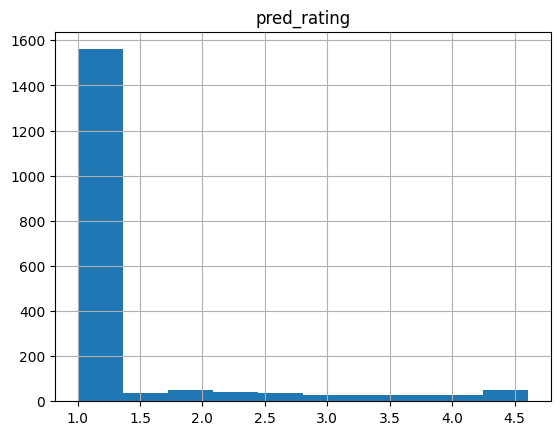

In [98]:
predictions.hist()

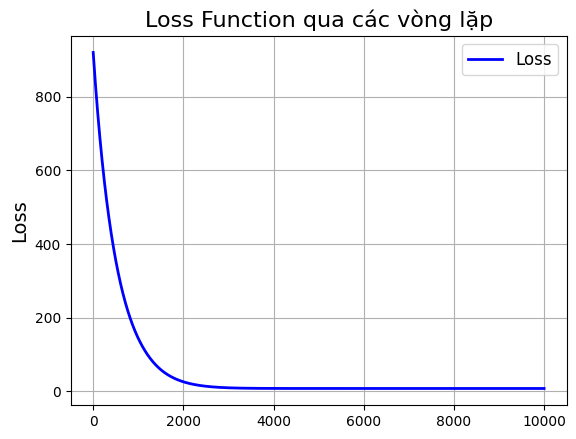

In [99]:
iterations = [t[0] for t in history]
loss_values = [t[1] for t in history]
rmse_values = [t[2] for t in history]

# Vẽ đồ thị Loss
plt.plot(iterations, loss_values, 'b-', linewidth=2, markersize=8, label='Loss')
plt.title('Loss Function qua các vòng lặp', fontsize=16)
plt.ylabel('Loss', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)


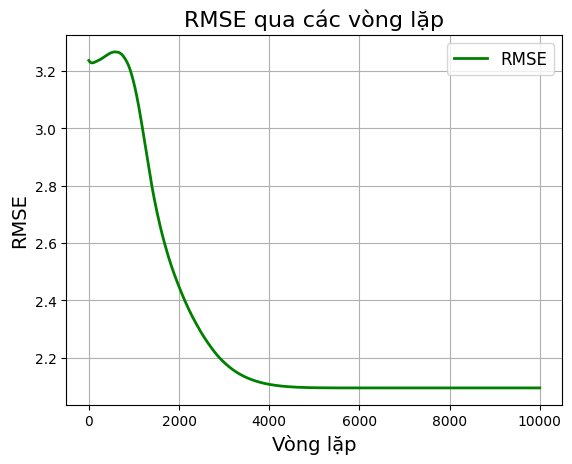

In [100]:
# Vẽ đồ thị RMSE
plt.plot(iterations, rmse_values, 'g-', linewidth=2, markersize=8, label='RMSE')
plt.title('RMSE qua các vòng lặp', fontsize=16)
plt.xlabel('Vòng lặp', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)

In [112]:
save_predictions(MF, "mf_predictions.npz")

Đã lưu ma trận dự đoán vào mf_predictions.npz


In [113]:
pred_matrix, user_ids, item_ids = load_predictions('/kaggle/working/mf_predictions.npz')

In [ ]:
recommendations = MF_recommend(pred_matrix, user_ids, item_ids, 11177, train_data=train_df,k=10)
print(recommendations)

     product_id  predicted_rating
316         361              4.61
22           28              4.58
470         544              4.57
52           62              4.55
168         193              4.54
23           29              4.54
1393       1612              4.54
364         419              4.53
135         156              4.52
581         663              4.52


## Xay dung FPMF

### B1

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# --- Bước 1: Các hàm tính toán Similarity ---

def s1(rij, rkj, r_med, a=1.0):
    """Tính s1 theo công thức (3.1)"""
    # a là hằng số, mặc định là 1.0
    numerator = -a * np.abs(rij - r_med) * np.abs(rkj - r_med)
    return 1 / (1 + np.exp(numerator))

def s2(rij, rkj, r_vj_avg, b=1.0):
    """Tính s2 theo công thức (3.2)"""
    # b là hằng số, mặc định là 1.0
    numerator = -b * np.abs(rij - r_vj_avg) * np.abs(rkj - r_vj_avg)
    return 1 / (1 + np.exp(numerator))

def calculate_S_ik(u_i_ratings, u_k_ratings, r_med, item_avg_ratings, a=1.0, b=1.0):
    """Tính S_ik (Extreme Behavior Similarity) theo công thức (3.3)"""
    # Tìm các item được cả hai user đánh giá (co-rated items)
    common_items_mask = (u_i_ratings > 0) & (u_k_ratings > 0)
    
    if not np.any(common_items_mask):
        return 0.0

    common_indices = np.where(common_items_mask)[0]
    
    s1_vals = []
    s2_vals = []

    for j in common_indices:
        rij = u_i_ratings[j]
        rkj = u_k_ratings[j]
        r_vj_avg = item_avg_ratings[j]
        
        s1_val = s1(rij, rkj, r_med, a)
        s2_val = s2(rij, rkj, r_vj_avg, b)
        
        s1_vals.append(s1_val)
        s2_vals.append(s2_val)

    s1_vals = np.array(s1_vals)
    s2_vals = np.array(s2_vals)

    # Triển khai công thức (3.3) với diễn giải hợp lý
    numerator = np.sum(s1_vals * s2_vals)
    denominator = np.sqrt(np.sum(s1_vals**2)) * np.sqrt(np.sum(s2_vals**2))

    if denominator == 0:
        return 0.0
        
    return numerator / denominator

def calculate_J(u_i_ratings, u_k_ratings):
    """Tính trọng số J (Jaccard similarity)"""
    i_rated_mask = u_i_ratings > 0
    k_rated_mask = u_k_ratings > 0
    
    intersection = np.sum(i_rated_mask & k_rated_mask)
    union = np.sum(i_rated_mask | k_rated_mask)
    
    if union == 0:
        return 0.0
        
    return intersection / union

### B2

In [4]:
from tqdm import tqdm

def calculate_G(R, theta, a=1.0, b=1.0):
    """
    Tính toán ma trận hàng xóm G dựa trên công thức (3.4) và (3.5).
    Đây là một bước tiền xử lý tốn kém về mặt tính toán.
    
    Args:
        R (np.array): Ma trận user-item.
        theta (float): Ngưỡng similarity.
        a, b (float): Các hằng số cho s1 và s2.

    Returns:
        np.array: Ma trận G (m x m).
    """
    n_users, n_items = R.shape
    G = np.zeros((n_users, n_users))

    # Tính các giá trị trung bình cần thiết trước
    # Lấy các rating khác 0 để tính toán
    non_zero_ratings = R[R > 0]
    r_med = np.median(non_zero_ratings) if len(non_zero_ratings) > 0 else 0
    
    # item_avg_ratings với xử lý cho các item không có rating
    item_avg_ratings = np.zeros(n_items)
    for j in range(n_items):
        item_ratings = R[:, j][R[:, j] > 0]
        if len(item_ratings) > 0:
            item_avg_ratings[j] = np.mean(item_ratings)
        else:
            item_avg_ratings[j] = r_med # Gán giá trị trung vị nếu item không có rating

    print("Calculating neighbor matrix G...")
    for i in tqdm(range(n_users)):
        for k in range(i + 1, n_users):
            u_i_ratings = R[i, :]
            u_k_ratings = R[k, :]
            
            # Tìm các item được cả hai user đánh giá
            common_mask = (u_i_ratings > 0) & (u_k_ratings > 0)
            
            if np.sum(common_mask) < 2: # Cần ít nhất 2 item chung để tính PCC
                s3 = 0.0
            else:
                # s3 là PCC
                s3, _ = pearsonr(u_i_ratings[common_mask], u_k_ratings[common_mask])
                if np.isnan(s3): # Xảy ra khi một vector rating không có phương sai
                    s3 = 0.0

            # Tính S_ik
            S_ik = calculate_S_ik(u_i_ratings, u_k_ratings, r_med, item_avg_ratings, a, b)
            
            # Tính J
            J = calculate_J(u_i_ratings, u_k_ratings)
            
            # Tính p_ms theo công thức (3.4)
            p_ms = J * s3 * S_ik
            
            # Áp dụng ngưỡng theta theo công thức (3.5)
            if p_ms > theta:
                G[i, k] = p_ms
                G[k, i] = p_ms # Ma trận đối xứng
    
    return G

### B3

In [5]:
from torch.utils.data import Dataset, DataLoader

class RatingDataset(Dataset):
    """Dataset cho các ratings."""
    def __init__(self, R_matrix):
        # Tìm các tọa độ và giá trị của các rating khác 0
        self.users, self.items = R_matrix.nonzero()
        self.ratings = R_matrix[self.users, self.items]

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

In [6]:
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

class FPMF(nn.Module):
    """
    Lớp Fusion Probability Matrix Factorization (FPMF).
    """
    def __init__(self, n_users, n_items, n_factors=10, lambda_u=0.01, lambda_v=0.01,  lambda_s=0.01, beta=0.1, batch_size=1024):
        """
        Khởi tạo mô hình.
        
        Args:
            n_users (int): Số lượng user.
            n_items (int): Số lượng item.
            n_factors (int): Số chiều của không gian latent (l).
            lambda_u (float): Tham số regularization cho user.
            lambda_v (float): Tham số regularization cho item.
            beta (float): Trọng số cho lỗi từ ma trận hàng xóm.
            lambda_s (float): Tham số regularization cho Graph Laplacian (λ_N).
        """
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_factors = n_factors
        self.lambda_u = lambda_u
        self.lambda_v = lambda_v
        self.lambda_s = lambda_s
        self.beta = beta
        self.batch_size = batch_size
        
        # Khởi tạo ma trận latent U và V với phân phối chuẩn
        # nn.Parameter để PyTorch biết cần tính gradient cho chúng
        self.U = nn.Parameter(torch.randn(n_users, n_factors))
        self.V = nn.Parameter(torch.randn(n_items, n_factors))

    def forward(self):
        """
        Tính toán ma trận rating dự đoán.
        R_hat = U * V^T
        """
        return self.U @ self.V.T

    def loss_function(self, R_tensor, G_tensor, I_tensor):
        """
        Tính toán hàm mất mát theo công thức (3.14).
        Lưu ý: Bài báo bỏ qua hệ số 1/2 và các hằng số khác.
        Chúng ta sẽ triển khai công thức L(Ui, Uk, Vj).
        """
        # Dự đoán
        R_pred = self.forward()
        G_pred = self.U.T @ self.U
        
        # 1. Lỗi rating (chỉ tính trên các rating đã biết)
        rating_error = torch.sum((I_tensor * (R_tensor - R_pred))**2)
        
        # 2. Lỗi hàng xóm (neighbor error)
        # G_tensor đã là ma trận thưa (0 ở những nơi không có kết nối)
        # nên ta có thể tính trên toàn ma trận.
        neighbor_error = torch.sum((G_tensor - G_pred)**2)
        
        # 3. Các thành phần Regularization
        reg_U = torch.sum(self.U**2)
        reg_V = torch.sum(self.V**2)
        
        # Tổng hợp loss
        # L = rating_error + beta * neighbor_error + lambda_u * reg_U + lambda_v * reg_V
        loss = rating_error + self.beta * neighbor_error + self.lambda_u * reg_U + self.lambda_v * reg_V
        return loss

    def fit(self, R_train, G, n_epochs=50, learning_rate=0.001):
        """
        Huấn luyện mô hình theo từng batch.
        
        Args:
            R_train (np.array): Ma trận rating huấn luyện.
            G (np.array): Ma trận hàng xóm.
            n_epochs (int): Số vòng lặp huấn luyện.
            learning_rate (float): Tốc độ học.
        """
        # Sử dụng Adam Optimizer theo yêu cầu
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)

        # Tạo DataLoader cho việc huấn luyện theo batch
        dataset = RatingDataset(R_train)
        data_loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        num_ratings = len(dataset)
        
        # Chuyển ma trận G sang tensor và tính ma trận Laplacian L
        G_tensor = torch.FloatTensor(G)
        D_tensor = torch.diag(torch.sum(G_tensor, dim=1))
        L_tensor = D_tensor - G_tensor # L = D - G

        print(f"Training FPMF model with {num_ratings} ratings, batch size {self.batch_size}...")
        for epoch in tqdm(range(n_epochs)):
            total_loss = 0.0
            for users_b, items_b, ratings_b in data_loader:
                # Xóa gradient cũ
                optimizer.zero_grad()
                
                # --- TÍNH TOÁN HÀM MẤT MÁT ---
                
                # 1. Lỗi rating (tính trên batch)
                u_vecs = self.U[users_b]
                v_vecs = self.V[items_b]
                preds = torch.sum(u_vecs * v_vecs, dim=1)
                rating_error = torch.sum((ratings_b.float() - preds)**2)
                
                # Scale lỗi rating để cân bằng với các lỗi tính trên toàn bộ ma trận
                scaled_rating_error = rating_error * (num_ratings / len(ratings_b))
                
                # 2. Lỗi hàng xóm (tính trên toàn bộ ma trận U)
                G_pred = self.U @ self.U.T # Sửa lỗi: U @ U.T thay vì U.T @ U
                neighbor_error = torch.sum((G_tensor - G_pred)**2)
                
                # 3. Regularization
                reg_U = torch.sum(self.U**2)
                reg_V = torch.sum(self.V**2)
                
                # 4. Graph Laplacian Regularization
                # Dựa trên diễn giải Tr(U^T * L * U)
                laplacian_reg = torch.trace(self.U.T @ L_tensor @ self.U)

                # Tổng hợp loss
                loss = (scaled_rating_error 
                        + self.beta * neighbor_error 
                        + self.lambda_u * reg_U 
                        + self.lambda_v * reg_V
                        + self.lambda_s * laplacian_reg) # Thêm vào loss
                
                # Lan truyền ngược và cập nhật
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(data_loader)
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_loss:.4f}")

    def get_predicted_matrix(self, clip_min=1.0, clip_max=5.0):
        """
        Trả về ma trận rating dự đoán hoàn chỉnh, với giá trị được giới hạn.
        
        Args:
            clip_min (float): Giá trị rating tối thiểu (ví dụ: 1).
            clip_max (float): Giá trị rating tối đa (ví dụ: 5).
            
        Returns:
            np.array: Ma trận dự đoán đã được giới hạn.
        """
        # Lấy ma trận dự đoán thô từ forward pass
        R_pred_tensor = self.forward()
        
        # Giới hạn (clamp/clip) giá trị của tensor dự đoán trong khoảng [min, max]
        R_pred_clipped = torch.clamp(R_pred_tensor, min=clip_min, max=clip_max)
        
        # Chuyển về numpy array để sử dụng bên ngoài
        return R_pred_clipped.detach().numpy()

    def evaluate(self, R_test):
        """
        Đánh giá mô hình trên tập test bằng MAE và RMSE.
        
        Args:
            R_test (np.array): Ma trận rating test.
            
        Returns:
            (float, float): (mae, rmse)
        """
        R_pred = self.get_predicted_matrix()
        
        # Lấy ra các giá trị cần đánh giá từ tập test
        test_mask = R_test > 0
        true_ratings = R_test[test_mask]
        pred_ratings = R_pred[test_mask]
        
        mae = mean_absolute_error(true_ratings, pred_ratings)
        rmse = np.sqrt(mean_squared_error(true_ratings, pred_ratings))
        
        return mae, rmse

In [7]:
def split_data(R, test_ratio=0.2):
    """
    Chia ma trận R thành tập train và test.
    
    Args:
        R (np.array): Ma trận user-item đầu vào.
        test_ratio (float): Tỷ lệ dữ liệu cho tập test.
        
    Returns:
        (np.array, np.array): (R_train, R_test)
    """
    # Tìm tọa độ của tất cả các rating đã biết (khác 0)
    user_indices, item_indices = np.where(R > 0)
    
    # Xáo trộn các tọa độ này một cách ngẫu nhiên
    num_ratings = len(user_indices)
    indices = np.arange(num_ratings)
    np.random.shuffle(indices)
    
    # Chia chỉ số
    num_test = int(test_ratio * num_ratings)
    test_indices = indices[:num_test]
    train_indices = indices[num_test:]
    
    # Tạo ma trận train và test
    R_train = np.zeros_like(R, dtype=np.float32)
    R_test = np.zeros_like(R, dtype=np.float32)
    
    # Điền giá trị vào ma trận train
    for idx in train_indices:
        u, i = user_indices[idx], item_indices[idx]
        R_train[u, i] = R[u, i]
        
    # Điền giá trị vào ma trận test
    for idx in test_indices:
        u, i = user_indices[idx], item_indices[idx]
        R_test[u, i] = R[u, i]
        
    return R_train, R_test

In [13]:
# Lấy danh sách user_id và product_id gốc
original_user_ids = df.index.tolist()
original_product_ids = df.columns.tolist()

# Tạo bản đồ từ ID gốc sang chỉ số vị trí (0, 1, 2...)
user_map = {user_id: i for i, user_id in enumerate(original_user_ids)}
product_map = {product_id: i for i, product_id in enumerate(original_product_ids)}

# Tạo bản đồ ngược từ chỉ số vị trí về ID gốc để diễn giải kết quả
user_map_inv = {i: user_id for user_id, i in user_map.items()}
product_map_inv = {i: product_id for product_id, i in product_map.items()}

R_full = usr_item_mx.values

print(f"Ma trận dữ liệu gốc có hình dạng: {R_full.shape}")
print(f"Độ thưa (sparsity): {1 - np.count_nonzero(R_full) / R_full.size:.4%}")

# --- 2. Chia dữ liệu (Bước 4) ---
R_train, R_test = split_data(R_full, test_ratio=0.2)
print(f"Tập train có {np.count_nonzero(R_train)} ratings.")
print(f"Tập test có {np.count_nonzero(R_test)} ratings.")

Ma trận dữ liệu gốc có hình dạng: (28477, 1885)
Độ thưa (sparsity): 0.0000%
Tập train có 72232 ratings.
Tập test có 18058 ratings.


In [ ]:


# --- 3. Tính ma trận hàng xóm G (Bước 2) ---
# Đây là bước tốn thời gian, nên thực hiện trên tập train
# Đặt theta nhỏ để có nhiều kết nối hơn trong ví dụ này
theta = 0.003 
G = calculate_G(R_train, theta)
print(f"Ma trận G được tạo, hình dạng: {G.shape}")
print(f"Số kết nối trong G: {np.count_nonzero(G) // 2}")


In [ ]:
# np.savez_compressed(g_matrix_path, g_matrix=G)

In [8]:
data = np.load('/kaggle/working/g_matrix.npz')
G = data['data']
shape = data['shape']

In [14]:
shape

array([28477, 28477])

In [ ]:
# --- 4. Huấn luyện và đánh giá mô hình FPMF (Bước 3) ---
# Thiết lập các siêu tham số cho mô hình
params = {
    'n_factors': 10,
    'lambda_u': 0.001,
    'lambda_v': 0.001,
    'lambda_s': 0.001,
    'beta': 0.3, # Tham số trọng số cho G
    'batch_size': 128
}

# Khởi tạo mô hình
model = FPMF(n_users=R_full.shape[0], n_items=R_full.shape[1], **params)

# Huấn luyện
model.fit(R_train, G, n_epochs=100, learning_rate=0.000125)

# Đánh giá
mae, rmse = model.evaluate(R_test)
print("\n--- Kết quả đánh giá trên tập test ---")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Lấy ma trận dự đoán hoàn chỉnh
R_predicted = model.get_predicted_matrix()
print("\nMa trận dự đoán hoàn chỉnh có hình dạng:", R_predicted.shape)
print("Ví dụ một vài dự đoán cho user 0:", R_predicted[0, :].round(2))

In [ ]:
def recommend_top_k(user_id, k, R_predicted, R_original):
    """
    Đề xuất top-K sản phẩm cho một người dùng cụ thể.
    
    Args:
        user_id (int): ID (chỉ số) của người dùng cần đề xuất.
        k (int): Số lượng sản phẩm muốn đề xuất.
        R_predicted (np.array): Ma trận user-item với các điểm đã được dự đoán.
        R_original (np.array): Ma trận user-item gốc để biết sản phẩm nào đã được đánh giá.
        
    Returns:
        pandas.DataFrame: Một DataFrame chứa 'item_id' và 'predicted_rating' 
                          cho K sản phẩm được đề xuất hàng đầu.
    """
    # 1. Lấy ra hàng dự đoán của người dùng
    user_predictions = R_predicted[user_id, :]
    
    # 2. Lấy ra các sản phẩm người dùng đã đánh giá từ ma trận gốc
    already_rated_indices = np.where(R_original[user_id, :] > 0)[0]
    
    # 3. Đặt điểm của các sản phẩm đã đánh giá về một giá trị rất thấp
    # để chúng không bao giờ được chọn.
    user_predictions[already_rated_indices] = -np.inf
    
    # 4. Sắp xếp và lấy ra K chỉ số (item_id) có điểm cao nhất
    # np.argsort trả về chỉ số của các phần tử sau khi đã sắp xếp.
    # Sắp xếp theo thứ tự giảm dần bằng cách thêm dấu trừ.
    top_k_item_indices = np.argsort(-user_predictions)[:k]
    
    # 5. Lấy điểm dự đoán tương ứng với các item hàng đầu
    top_k_scores = R_predicted[user_id, top_k_item_indices]
    
    # 6. Tạo DataFrame để trả về kết quả một cách rõ ràng
    recommendations_df = pd.DataFrame({
        'item_id': top_k_item_indices,
        'predicted_rating': top_k_scores
    })
    
    return recommendations_df

In [ ]:
target_user_idx = user_map[target_original_user_id]

print(f"\n--- Đề xuất Top {num_recommendations} sản phẩm cho User ID gốc: {target_original_user_id} (chỉ số vị trí: {target_user_idx}) ---")

# Gọi hàm đề xuất với chỉ số vị trí
top_k_recs = recommend_top_k(
    user_id=target_user_idx,
    k=num_recommendations,
    R_predicted=R_predicted_clipped, # Giả sử đã có ma trận dự đoán
    R_original=R_full
)

# Dùng bản đồ ngược để chuyển đổi item_id (chỉ số vị trí) về product_id gốc
top_k_recs['original_product_id'] = top_k_recs['item_id'].map(product_map_inv)

print("\nCác sản phẩm được đề xuất (với Product ID gốc):")
print(top_k_recs[['original_product_id', 'predicted_rating']])